## 🎯 Objective

The objective of this project is to analyze sales data to extract meaningful business insights.

This analysis aims to:
- Calculate total revenue generated from sales
- Identify top-performing products and categories
- Determine which cities contribute the most to revenue
- Analyze monthly sales trends
- Understand customer payment behavior

The goal is to simulate real-world business decision-making using data analysis techniques.

In [40]:
import pandas as pd

In [41]:
df=pd.read_csv("sales_data.csv")

In [42]:
df

,OrderID,CustomerID,Product,Category,City,Price,Quantity,Date,PaymentMode
0,1001,C101,Laptop,Electronics,Kolkata,55000,1,15-01-2024,UPI
1,1002,C102,Phone,Electronics,Delhi,20000,2,16-01-2024,Credit Card
2,1003,C103,Shoes,Fashion,Mumbai,3000,1,17-01-2024,Cash
3,1004,C101,Headphones,Electronics,Kolkata,1500,2,01-02-2024,UPI
4,1005,C104,T-Shirt,Fashion,Bangalore,800,3,03-02-2024,Debit Card
5,1006,C105,Laptop,Electronics,Delhi,60000,1,10-02-2024,Credit Card
6,1007,C106,Watch,Accessories,Mumbai,2500,2,15-02-2024,UPI
7,1008,C102,Shoes,Fashion,Delhi,3500,1,01-03-2024,Cash
8,1009,C107,Phone,Electronics,Kolkata,18000,1,05-03-2024,UPI
9,1010,C108,Backpack,Accessories,Bangalore,1200,2,08-03-2024,Debit Card


In [43]:
df.tail()

,OrderID,CustomerID,Product,Category,City,Price,Quantity,Date,PaymentMode
7,1008,C102,Shoes,Fashion,Delhi,3500,1,01-03-2024,Cash
8,1009,C107,Phone,Electronics,Kolkata,18000,1,05-03-2024,UPI
9,1010,C108,Backpack,Accessories,Bangalore,1200,2,08-03-2024,Debit Card
10,1011,C109,Laptop,Electronics,Mumbai,58000,1,12-03-2024,Credit Card
11,1012,C110,T-Shirt,Fashion,Kolkata,900,2,15-03-2024,Cash


In [44]:
df.notnull()

,OrderID,CustomerID,Product,Category,City,Price,Quantity,Date,PaymentMode
0,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True
5,True,True,True,True,True,True,True,True,True
6,True,True,True,True,True,True,True,True,True
7,True,True,True,True,True,True,True,True,True
8,True,True,True,True,True,True,True,True,True
9,True,True,True,True,True,True,True,True,True


In [66]:
#Calculate total revenue generated from sales
df['Revenue']=df['Price']*df['Quantity']
Total_Revenue=df['Revenue'].sum()
print("Total Revenue::",Total_Revenue)

Total Revenue:: 252100


The company generated a total revenue of ₹252100 during the given period.

#Identify top-performing products and categories

In [51]:
#Top Products
top_performing_products=df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(3)
print(top_performing_products)

Product
Laptop    173000
Phone      58000
Shoes       6500
Name: Revenue, dtype: int64


Product Laptop is the highest revenue generator, contributing significantly to total sales.

In [53]:
#Top categories
top_categories=df.groupby('Category')['Revenue'].sum().sort_values(ascending=False).head()
print(top_categories)

Category
Electronics    234000
Fashion         10700
Accessories      7400
Name: Revenue, dtype: int64


 categorie Electronics is the highest revenue generator.

In [56]:
#Determine which cities contribute the most to revenue
cities_revenue=df.groupby('City')["Revenue"].sum().sort_values(ascending=False)
print(cities_revenue)

City
Delhi        103500
Kolkata       77800
Mumbai        66000
Bangalore      4800
Name: Revenue, dtype: int64


City Delhi contributes the highest share of revenue, indicating strong market demand.

In [58]:
#Analyze monthly sales trends
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

df

,OrderID,CustomerID,Product,Category,City,Price,Quantity,Date,PaymentMode,Revenue,Month
0,1001,C101,Laptop,Electronics,Kolkata,55000,1,2024-01-15,UPI,55000,2024-01
1,1002,C102,Phone,Electronics,Delhi,20000,2,2024-01-16,Credit Card,40000,2024-01
2,1003,C103,Shoes,Fashion,Mumbai,3000,1,2024-01-17,Cash,3000,2024-01
3,1004,C101,Headphones,Electronics,Kolkata,1500,2,2024-02-01,UPI,3000,2024-02
4,1005,C104,T-Shirt,Fashion,Bangalore,800,3,2024-02-03,Debit Card,2400,2024-02
5,1006,C105,Laptop,Electronics,Delhi,60000,1,2024-02-10,Credit Card,60000,2024-02
6,1007,C106,Watch,Accessories,Mumbai,2500,2,2024-02-15,UPI,5000,2024-02
7,1008,C102,Shoes,Fashion,Delhi,3500,1,2024-03-01,Cash,3500,2024-03
8,1009,C107,Phone,Electronics,Kolkata,18000,1,2024-03-05,UPI,18000,2024-03
9,1010,C108,Backpack,Accessories,Bangalore,1200,2,2024-03-08,Debit Card,2400,2024-03


In [60]:
monthly_sales = df.groupby('Month')['Revenue'].sum()
print(monthly_sales)

Month
2024-01    98000
2024-02    70400
2024-03    83700
Freq: M, Name: Revenue, dtype: int64


Sales peaked in Month 01, possibly due to seasonal demand or promotions.

In [64]:
#Understand customer payment behavior
payment_analysis = df.groupby('PaymentMode')['Revenue'].sum().sort_values(ascending=False)
print(payment_analysis)

PaymentMode
Credit Card    158000
UPI             81000
Cash             8300
Debit Card       4800
Name: Revenue, dtype: int64


Most customers prefer UPI, indicating a shift toward digital payments.

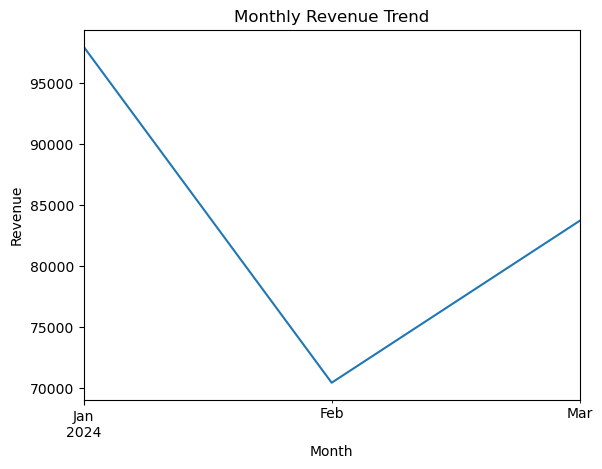

In [67]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind='line')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()